# Notebook 07 — Gap Closure + Real Ablation Study

נוטבוק **עצמאי וחדש**, לא נוגע בקבצים או בנוטבוקים 03/04/05/06 הקיימים. קורא רק את הקבצים הקיימים:
`metadata.csv` (גולמי, לפני ניקוי), `clean_metadata.csv`, `train.csv`, `val.csv`, `test.csv`.

**מה סוגר הנוטבוק הזה:**
1. Mislabeled Data Detection (זיהוי תיוגים חשודים, לא הוסר עד כה)
2. Outliers Detection (מימדי תמונה חריגים)
3. Ablation Study אמיתי — 4 שלבים, כל שלב משנה **משתנה אחד בלבד**:
   - שלב 1 — Baseline גולמי: נתונים לא-מנוקים (כולל כפילויות), בלי Augmentation, בלי Pretrained Weights
   - שלב 2 — + Cleaning: נתונים מנוקים (train/val/test הקיימים), בלי Augmentation, בלי Pretrained
   - שלב 3 — + Augmentation: נתונים מנוקים + Augmentation, בלי Pretrained
   - שלב 4 — Transfer Learning מלא: נתונים מנוקים + Augmentation + Pretrained Weights
4. Test Accuracy אמיתי לכל שלב (לא Validation!), Confusion Matrix מנורמל לשלב הסופי, ובדיקת קריטריון ההצלחה (15% שיפור).

## ⚠️ לפני שמריצים הכל: זמן ריצה

זה כולל **4 אימונים מלאים** של ResNet50 (ולא אחד). על CPU זה יכול לקחת זמן ניכר. יש בהמשך תא שמודד זמן ל-batch בודד ומעריך את הזמן הכולל *לפני* שמתחילים בפועל — תריצי אותו קודם ותחליטי אם להמשיך, להקטין `ABLATION_EPOCHS`, או לעבור ל-Google Colab עם GPU.


## 1. ייבוא ספריות והגדרות בסיס

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
# קריאה בלבד - אין כתיבה חזרה לאף קובץ מקורי
raw_metadata_df = pd.read_csv("../data/processed/metadata.csv")      # גולמי, לפני ניקוי
clean_df = pd.read_csv("../data/processed/clean_metadata.csv")        # אחרי הסרת כפילויות
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")

# תיקון: clean_metadata.csv נשמר בלי עמודת emoji_name (רק file_name/platform/hash).
# משחזרים אותה בעזרת merge מול המטאדאטה הגולמית, לפי file_name + platform יחד.
clean_df = clean_df.merge(
    raw_metadata_df[["file_name", "platform", "emoji", "emoji_name"]].drop_duplicates(),
    on=["file_name", "platform"],
    how="left"
)

missing_emoji_name = clean_df["emoji_name"].isna().sum()
print("שורות בלי emoji_name אחרי המיזוג (אמור להיות 0):", missing_emoji_name)

print("Raw (before cleaning):", len(raw_metadata_df))
print("Clean:", len(clean_df))
print("Existing split -> Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

platforms = sorted(clean_df["platform"].unique())
label_map = {platform: idx for idx, platform in enumerate(platforms)}
print(label_map)


שורות בלי emoji_name אחרי המיזוג (אמור להיות 0): 0
Raw (before cleaning): 12169
Clean: 12001
Existing split -> Train: 8400 Val: 1800 Test: 1801
{'Apple': 0, 'Facebook': 1, 'Google': 2, 'JoyPixels': 3, 'Samsung': 4, 'Twitter': 5, 'Windows': 6}


## 2. Outlier Detection

בדיקה קלה ומהירה (בלי מודל) — מימדי תמונה חריגים ביחס לשאר הדאטהסט.

In [4]:
def get_image_size(row, df_source):
    path = f"../data/processed/{row['platform']}/{row['file_name']}"
    try:
        with Image.open(path) as img:
            return img.size  # (width, height)
    except Exception:
        return (None, None)

sizes = clean_df.apply(lambda r: get_image_size(r, clean_df), axis=1)
clean_df_sizes = clean_df.copy()
clean_df_sizes["width"] = [s[0] for s in sizes]
clean_df_sizes["height"] = [s[1] for s in sizes]

print(clean_df_sizes[["width", "height"]].describe())


              width        height
count  12001.000000  12001.000000
mean      72.006000     72.006000
std        0.464719      0.464719
min       72.000000     72.000000
25%       72.000000     72.000000
50%       72.000000     72.000000
75%       72.000000     72.000000
max      108.000000    108.000000


In [5]:
# חריגים = מחוץ ל-3 סטיות תקן מהממוצע, בכל אחד מהצירים
w_mean, w_std = clean_df_sizes["width"].mean(), clean_df_sizes["width"].std()
h_mean, h_std = clean_df_sizes["height"].mean(), clean_df_sizes["height"].std()

outliers_mask = (
    (clean_df_sizes["width"] - w_mean).abs() > 3 * w_std
) | (
    (clean_df_sizes["height"] - h_mean).abs() > 3 * h_std
)

outliers_df = clean_df_sizes[outliers_mask]
print("Outlier images found (unusual dimensions):", len(outliers_df))
outliers_df[["file_name", "platform", "width", "height"]].head(20)


Outlier images found (unusual dimensions): 2


,file_name,platform,width,height
4448,garlic_678.png,Samsung,108,108
4455,onion_679.png,Samsung,108,108


## 3. Mislabeled Data Detection

שיטה: Average Hash (aHash) פרספטואלי לכל תמונה — resize ל-8x8, grayscale, סף מול הממוצע. לכל קבוצת `emoji_name` (אותו אימוג'י על פני כל הפלטפורמות) מחושב hash "ייצוגי" (הצבעת רוב על כל ביט), ותמונות שרחוקות מדי ממנו (Hamming Distance גבוה) מסומנות כמועמדות ל-Mislabel לבדיקה ידנית.

**הערה:** זו שיטת סינון (Flagging) לבדיקה, לא מחיקה אוטומטית — מומלץ לבדוק ידנית כמה דוגמאות מהרשימה שתתקבל לפני כל החלטה על הסרה.

In [6]:
def average_hash(image_path, hash_size=8):
    with Image.open(image_path) as img:
        img = img.convert("L").resize((hash_size, hash_size), Image.LANCZOS)
        pixels = np.asarray(img, dtype=np.float64)
    avg = pixels.mean()
    return (pixels > avg).flatten()  # boolean array length hash_size*hash_size

def hamming_distance(a, b):
    return np.count_nonzero(a != b)


In [7]:
hashes = []
for _, row in clean_df.iterrows():
    path = f"../data/processed/{row['platform']}/{row['file_name']}"
    try:
        h = average_hash(path)
    except Exception:
        h = None
    hashes.append(h)

clean_df_hash = clean_df.copy()
clean_df_hash["ahash"] = hashes
print("Hashes computed:", clean_df_hash['ahash'].notna().sum(), "/", len(clean_df_hash))


C:\Users\chagitmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Hashes computed: 12001 / 12001


In [8]:
mislabel_candidates = []
THRESHOLD_BITS = 20  # מתוך 64 ביטים - סף לניסוי ראשוני, אפשר לכוונן

for emoji_name, group in clean_df_hash.groupby("emoji_name"):
    valid = group[group["ahash"].notna()]
    if len(valid) < 2:
        continue

    stacked = np.stack(valid["ahash"].values)
    reference = (stacked.mean(axis=0) > 0.5)  # הצבעת רוב לכל ביט - ה"טיפוסי" של הקבוצה

    for idx, row in valid.iterrows():
        dist = hamming_distance(row["ahash"], reference)
        if dist > THRESHOLD_BITS:
            mislabel_candidates.append({
                "file_name": row["file_name"],
                "platform": row["platform"],
                "emoji_name": emoji_name,
                "hamming_distance": dist
            })

mislabel_df = pd.DataFrame(mislabel_candidates).sort_values("hamming_distance", ascending=False)
print("Mislabel/anomaly candidates found:", len(mislabel_df))
mislabel_df.head(20)


Mislabel/anomaly candidates found: 2933


,file_name,platform,emoji_name,hamming_distance
2761,white_small_square_1536.png,Samsung,white small square,64
237,black_small_square_1535.png,JoyPixels,black small square,64
2744,white_exclamation_mark_1435.png,Samsung,white exclamation mark,63
2759,white_question_mark_1434.png,Samsung,white question mark,63
651,dress_1089.png,Samsung,dress,62
178,battery_1155.png,Samsung,battery,62
1235,fork_and_knife_774.png,Samsung,fork and knife,62
1924,old_man_233.png,Samsung,old man,61
2207,raised_hand_159.png,Samsung,raised hand,61
2206,raised_fist_177.png,Samsung,raised fist,61


## 4. Dataset ו-Transforms

In [9]:
class EmojiDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = f"../data/processed/{row['platform']}/{row['file_name']}"
        image = Image.open(image_path).convert("RGB")
        label = label_map[row["platform"]]
        if self.transform:
            image = self.transform(image)
        return image, label


In [10]:
no_aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])


## 5. פונקציות עזר משותפות ל-4 השלבים

כדי שה-Ablation יהיה הוגן, כל 4 השלבים משתמשים באותה פונקציית אימון/הערכה בדיוק — משתנה רק הקונפיגורציה (נתונים / Augmentation / Pretrained).

In [11]:
def build_model(pretrained: bool, num_classes: int = 7):
    if pretrained:
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else:
        model = models.resnet50(weights=None)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)


In [12]:
def estimate_runtime(model, loader, epochs):
    """מריץ batch בודד (forward+backward) ומעריך זמן כולל לפני שמתחילים בפועל."""
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    start = time.time()
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    single_batch_time = time.time() - start

    total_batches = len(loader) * epochs
    estimated_seconds = single_batch_time * total_batches
    print(f"זמן ל-batch בודד: {single_batch_time:.2f}s | סה\"כ batches (train בלבד, {epochs} epochs): {total_batches}")
    print(f"הערכת זמן ל-Train בלבד (לא כולל Validation/Test): ~{estimated_seconds/60:.1f} דקות")
    return estimated_seconds


In [13]:
def train_and_evaluate(model, train_loader, val_loader, test_loader, epochs, stage_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        epoch_start = time.time()

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - epoch_start
        print(f"[{stage_name}] Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    # Test evaluation + predictions for Confusion Matrix
    model.eval()
    test_correct, test_total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (preds.cpu() == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    test_acc = test_correct / test_total
    print(f"[{stage_name}] TEST ACCURACY: {test_acc:.4f}")

    return {
        "history": history,
        "test_acc": test_acc,
        "all_preds": all_preds,
        "all_labels": all_labels
    }


In [14]:
ABLATION_EPOCHS = 3  # זהה בכל 4 השלבים, לצורך השוואה הוגנת. הקטיני ל-1 אם הזמן לא מספיק.
BATCH_SIZE = 32


## שלב 1 — Baseline גולמי (נתונים לא-מנוקים, בלי Augmentation, בלי Pretrained)

פיצול טרי מתוך `metadata.csv` הגולמי (**כולל** כפילויות) — ממחיש בפועל את ההשפעה של Data Leakage כתוצאה מכפילויות בין הפיצולים, בדיוק כפי שהמטלה מתייחסת לנושא.

In [14]:
raw_train_df, raw_temp_df = train_test_split(
    raw_metadata_df, test_size=0.30, stratify=raw_metadata_df["platform"], random_state=42
)
raw_val_df, raw_test_df = train_test_split(
    raw_temp_df, test_size=0.50, stratify=raw_temp_df["platform"], random_state=42
)
print("Stage 1 split -> Train:", len(raw_train_df), "Val:", len(raw_val_df), "Test:", len(raw_test_df))

stage1_train_loader = DataLoader(EmojiDataset(raw_train_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=True)
stage1_val_loader = DataLoader(EmojiDataset(raw_val_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)
stage1_test_loader = DataLoader(EmojiDataset(raw_test_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)


Stage 1 split -> Train: 8518 Val: 1825 Test: 1826


In [15]:
# הרצת מדידת זמן לפני האימון המלא - תריצי את התא הזה קודם ובדקי אם הזמן המוערך סביר
_ = estimate_runtime(build_model(pretrained=False), stage1_train_loader, ABLATION_EPOCHS)


C:\Users\chagitmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


זמן ל-batch בודד: 8.02s | סה"כ batches (train בלבד, 3 epochs): 801
הערכת זמן ל-Train בלבד (לא כולל Validation/Test): ~107.0 דקות


In [16]:
stage1_model = build_model(pretrained=False)
stage1_result = train_and_evaluate(
    stage1_model, stage1_train_loader, stage1_val_loader, stage1_test_loader,
    ABLATION_EPOCHS, "Stage 1 - Raw Baseline"
)


[Stage 1 - Raw Baseline] Epoch 1/3 | Train Acc: 0.2833 | Val Acc: 0.2181 | Time: 1957.6s
[Stage 1 - Raw Baseline] Epoch 2/3 | Train Acc: 0.3717 | Val Acc: 0.4822 | Time: 1814.1s
[Stage 1 - Raw Baseline] Epoch 3/3 | Train Acc: 0.4131 | Val Acc: 0.5085 | Time: 1607.6s
[Stage 1 - Raw Baseline] TEST ACCURACY: 0.4989


## שלב 2 — + Cleaning (נתונים מנוקים, בלי Augmentation, בלי Pretrained)

In [17]:
stage2_train_loader = DataLoader(EmojiDataset(train_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=True)
stage2_val_loader = DataLoader(EmojiDataset(val_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)
stage2_test_loader = DataLoader(EmojiDataset(test_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)

stage2_model = build_model(pretrained=False)
stage2_result = train_and_evaluate(
    stage2_model, stage2_train_loader, stage2_val_loader, stage2_test_loader,
    ABLATION_EPOCHS, "Stage 2 - Cleaned Data"
)


[Stage 2 - Cleaned Data] Epoch 1/3 | Train Acc: 0.3485 | Val Acc: 0.3511 | Time: 1898.1s
[Stage 2 - Cleaned Data] Epoch 2/3 | Train Acc: 0.4054 | Val Acc: 0.4078 | Time: 2035.4s
[Stage 2 - Cleaned Data] Epoch 3/3 | Train Acc: 0.4393 | Val Acc: 0.4211 | Time: 1858.3s
[Stage 2 - Cleaned Data] TEST ACCURACY: 0.4275


## שלב 3 — + Augmentation (נתונים מנוקים + Augmentation, בלי Pretrained)

In [18]:
stage3_train_loader = DataLoader(EmojiDataset(train_df, aug_transform), batch_size=BATCH_SIZE, shuffle=True)
stage3_val_loader = DataLoader(EmojiDataset(val_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)
stage3_test_loader = DataLoader(EmojiDataset(test_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)

stage3_model = build_model(pretrained=False)
stage3_result = train_and_evaluate(
    stage3_model, stage3_train_loader, stage3_val_loader, stage3_test_loader,
    ABLATION_EPOCHS, "Stage 3 - Cleaned + Augmentation"
)


[Stage 3 - Cleaned + Augmentation] Epoch 1/3 | Train Acc: 0.2602 | Val Acc: 0.4000 | Time: 1562.1s
[Stage 3 - Cleaned + Augmentation] Epoch 2/3 | Train Acc: 0.3493 | Val Acc: 0.3689 | Time: 1657.3s
[Stage 3 - Cleaned + Augmentation] Epoch 3/3 | Train Acc: 0.3740 | Val Acc: 0.4894 | Time: 1713.7s
[Stage 3 - Cleaned + Augmentation] TEST ACCURACY: 0.4997


## שלב 4 — Transfer Learning מלא (נתונים מנוקים + Augmentation + Pretrained Weights)

In [15]:
stage4_train_loader = DataLoader(EmojiDataset(train_df, aug_transform), batch_size=BATCH_SIZE, shuffle=True)
stage4_val_loader = DataLoader(EmojiDataset(val_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)
stage4_test_loader = DataLoader(EmojiDataset(test_df, no_aug_transform), batch_size=BATCH_SIZE, shuffle=False)

stage4_model = build_model(pretrained=True)
stage4_result = train_and_evaluate(
    stage4_model, stage4_train_loader, stage4_val_loader, stage4_test_loader,
    ABLATION_EPOCHS, "Stage 4 - Full Transfer Learning"
)


C:\Users\chagitmi\AppData\Local\Programs\Python\Python314\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Stage 4 - Full Transfer Learning] Epoch 1/3 | Train Acc: 0.6826 | Val Acc: 0.7617 | Time: 1885.9s
[Stage 4 - Full Transfer Learning] Epoch 2/3 | Train Acc: 0.8007 | Val Acc: 0.7922 | Time: 1912.6s
[Stage 4 - Full Transfer Learning] Epoch 3/3 | Train Acc: 0.8257 | Val Acc: 0.8056 | Time: 1580.7s
[Stage 4 - Full Transfer Learning] TEST ACCURACY: 0.7962


## 6. Ablation Study — גרף השוואה בין 4 השלבים (Test Accuracy)

C:\Users\chagitmi\AppData\Local\Temp\ipykernel_5348\1274408987.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ablation_results.keys()), y=list(ablation_results.values()), palette="Blues_d")


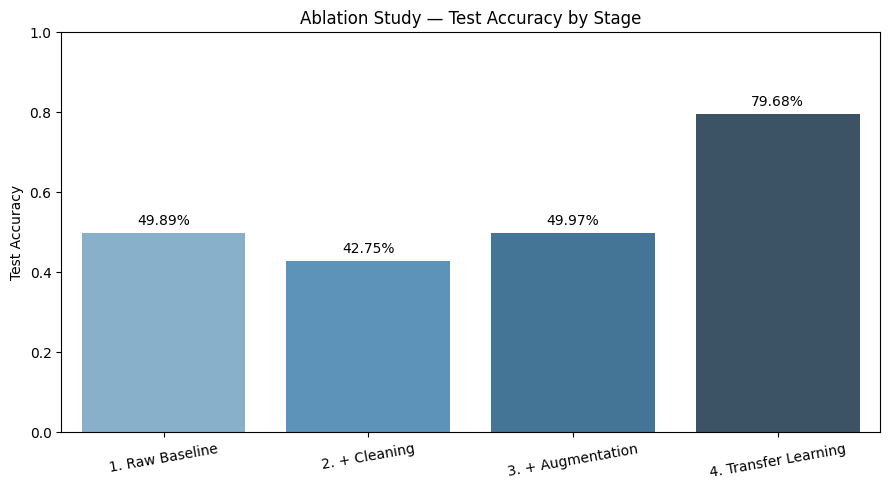

{'1. Raw Baseline': 0.49890470974808326, '2. + Cleaning': 0.4275402554136591, '3. + Augmentation': 0.4997223764575236, '4. Transfer Learning': 0.7967795669072737}


In [20]:
ablation_results = {
    "1. Raw Baseline": stage1_result["test_acc"],
    "2. + Cleaning": stage2_result["test_acc"],
    "3. + Augmentation": stage3_result["test_acc"],
    "4. Transfer Learning": stage4_result["test_acc"],
}

plt.figure(figsize=(9, 5))
sns.barplot(x=list(ablation_results.keys()), y=list(ablation_results.values()), palette="Blues_d")
plt.title("Ablation Study — Test Accuracy by Stage")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(ablation_results.values()):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print(ablation_results)


## 7. השוואת שיפור מול ה-Baseline (לפי הבהרת המורה: כל שיפור נחשב חיובי, לא חובה 15%)


In [21]:
baseline_acc = stage1_result["test_acc"]
final_acc = stage4_result["test_acc"]

improvement_pct = (final_acc - baseline_acc) / baseline_acc * 100
improvement_points = (final_acc - baseline_acc) * 100  # שיפור בנקודות אחוז (Percentage Points)

print(f"Baseline (Stage 1) Test Accuracy: {baseline_acc:.4f}")
print(f"Final Model (Stage 4) Test Accuracy: {final_acc:.4f}")
print(f"שיפור יחסי: {improvement_pct:.1f}%")
print(f"שיפור בנקודות אחוז: {improvement_points:.1f} נקודות אחוז")

# לפי הבהרת המורה בעל-פה: לא חובה 15% מדויק - העיקר שיש שיפור כלשהו
if final_acc > baseline_acc:
    print("✅ יש שיפור לעומת ה-Baseline (הדרישה בפועל, לפי המורה)")
else:
    print("❌ אין שיפור - כדאי לבדוק את הקונפיגורציה של שלב 4")


Baseline (Stage 1) Test Accuracy: 0.4989
Final Model (Stage 4) Test Accuracy: 0.7968
שיפור יחסי: 59.7%
שיפור בנקודות אחוז: 29.8 נקודות אחוז
✅ יש שיפור לעומת ה-Baseline (הדרישה בפועל, לפי המורה)


## 8. Confusion Matrix מנורמל — המודל הסופי (שלב 4)

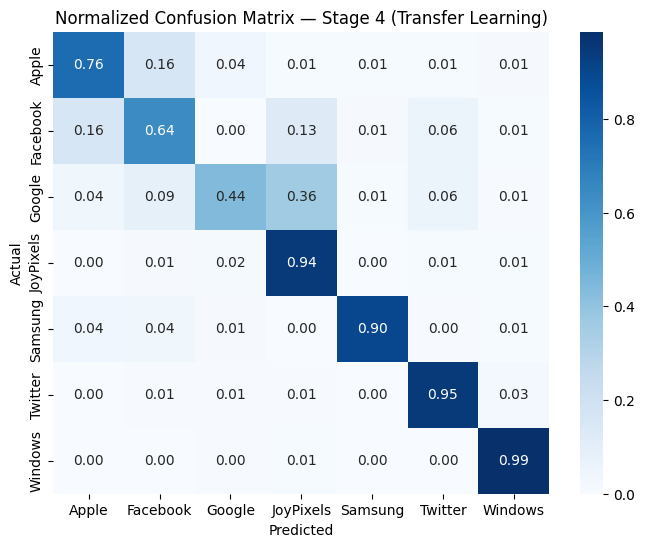

In [22]:
class_names = [name for name, idx in sorted(label_map.items(), key=lambda x: x[1])]

cm = confusion_matrix(stage4_result["all_labels"], stage4_result["all_preds"], normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix — Stage 4 (Transfer Learning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## סיכום

כל המספרים בתא האחרון מוכנים להעתקה ישירה למצגת (שקופיות Ablation Study וקריטריון ההצלחה).

תזכורת: תוצאת ה-EfficientNet-B0 מ-`06_augmentation_experiment_v2.ipynb` (Notebook הקיים, לא נגעתי בו) יכולה להיות מוצגת בנפרד כהשוואת ארכיטקטורות נוספת, מעבר לשרשרת ה-Ablation בת 4 השלבים כאן.

In [23]:
print("Summary for presentation:")
print("Outliers found:", len(outliers_df))
print("Mislabel candidates found:", len(mislabel_df))
print()
for k, v in ablation_results.items():
    print(f"{k}: {v:.2%}")
print()
print(f"Improvement (Stage 1 -> Stage 4): {improvement_pct:.1f}%")


Summary for presentation:
Outliers found: 2
Mislabel candidates found: 2933

1. Raw Baseline: 49.89%
2. + Cleaning: 42.75%
3. + Augmentation: 49.97%
4. Transfer Learning: 79.68%

Improvement (Stage 1 -> Stage 4): 59.7%


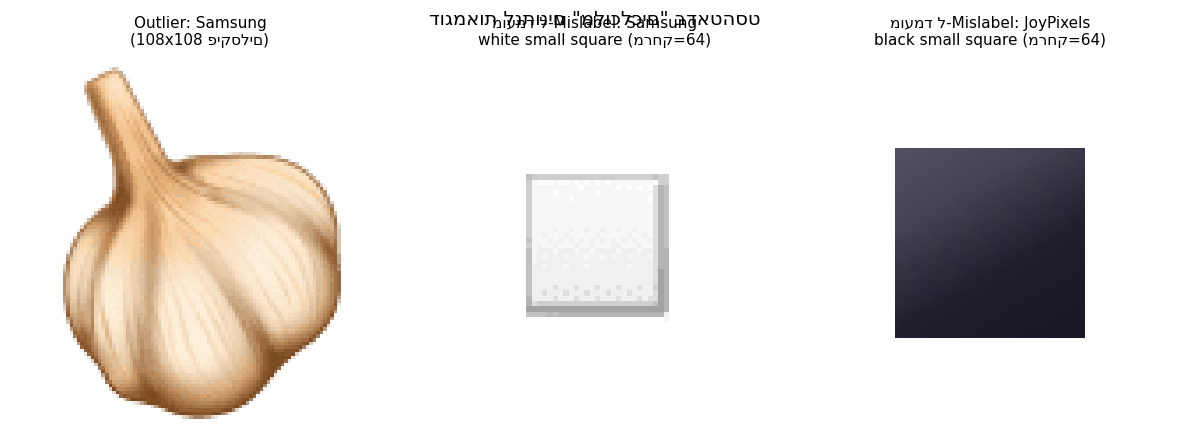

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

examples = []

if len(outliers_df) > 0:
    row = outliers_df.iloc[0]
    examples.append((f"../data/processed/{row['platform']}/{row['file_name']}",
                      f"Outlier: {row['platform']}\n({row['width']}x{row['height']} פיקסלים)"))

for _, row in mislabel_df.head(2).iterrows():
    examples.append((f"../data/processed/{row['platform']}/{row['file_name']}",
                      f"מועמד ל-Mislabel: {row['platform']}\n{row['emoji_name']} (מרחק={row['hamming_distance']})"))

fig, axes = plt.subplots(1, len(examples), figsize=(4*len(examples), 4.5))
if len(examples) == 1:
    axes = [axes]
for ax, (path, title) in zip(axes, examples):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('דוגמאות לנתונים "מלוכלכים" בדאטהסט', fontsize=14)
plt.tight_layout()
plt.savefig("dirty_data_examples.png", dpi=150, bbox_inches='tight')
plt.show()

סה"כ טעויות בסט הטסט: 367 מתוך 1801


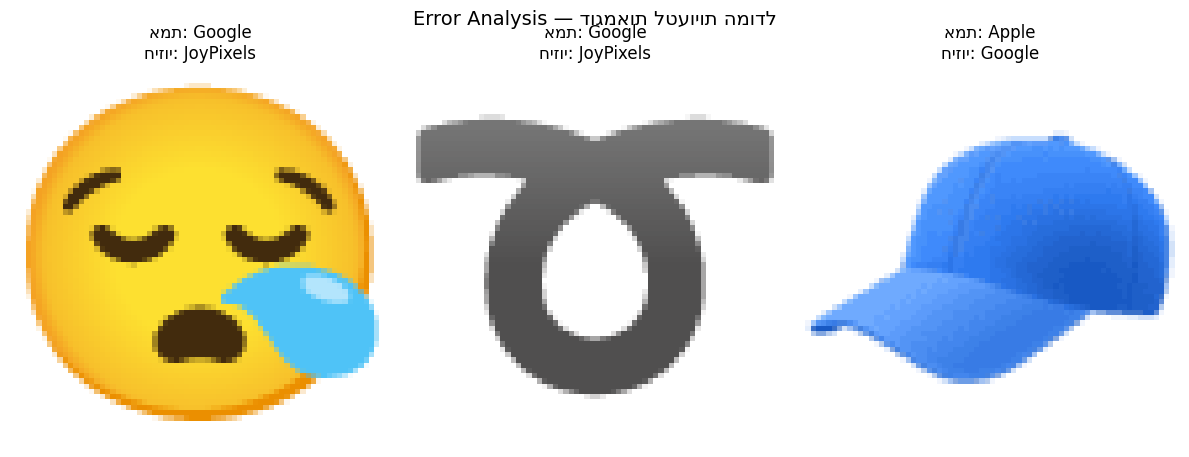

In [17]:
class_names_list = [name for name, idx in sorted(label_map.items(), key=lambda x: x[1])]

wrong_indices = [i for i, (p, l) in enumerate(zip(stage4_result["all_preds"], stage4_result["all_labels"])) if p != l]
print("סה\"כ טעויות בסט הטסט:", len(wrong_indices), "מתוך", len(stage4_result["all_labels"]))

sample_wrong = wrong_indices[:3]

fig, axes = plt.subplots(1, len(sample_wrong), figsize=(4*len(sample_wrong), 4.8))
if len(sample_wrong) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_wrong):
    row = test_df.iloc[idx]
    path = f"../data/processed/{row['platform']}/{row['file_name']}"
    img = Image.open(path)
    true_label = class_names_list[stage4_result["all_labels"][idx]]
    pred_label = class_names_list[stage4_result["all_preds"][idx]]
    ax.imshow(img)
    ax.set_title(f"אמת: {true_label}\nחיזוי: {pred_label}", fontsize=12)
    ax.axis('off')

plt.suptitle("Error Analysis — דוגמאות לטעויות המודל", fontsize=14)
plt.tight_layout()
plt.savefig("error_analysis_examples.png", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print(stage4_result["history"])

{'train_loss': [1.0405396476897903, 0.6319248693297571, 0.5351590497185522], 'val_loss': [0.7646179999175825, 0.6383116229584342, 0.5795977405811611], 'train_acc': [0.6826190476190476, 0.8007142857142857, 0.8257142857142857], 'val_acc': [0.7616666666666667, 0.7922222222222223, 0.8055555555555556]}
